In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os
import cv2
from PIL import Image
import numpy as np #linear algebra
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt #data visualizing
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.datasets as datasets
from torchvision.transforms import v2 as transforms
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn import svm
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
print("Success")


Success


In [3]:
import kagglehub
path = kagglehub.dataset_download("obulisainaren/multi-cancer")

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
from torchvision.transforms import v2 as transforms
from sklearn.metrics import classification_report, confusion_matrix
import random
import numpy as np
from torch import amp
from tqdm import tqdm
from sklearn.utils.class_weight import compute_class_weight

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


class CancerCNN(nn.Module):
    def __init__(self, num_classes=26, class_weights = None):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),   # Out (112,112)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1),  # Out (112,112)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                                          # Out (56,56)
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1), # Out (56,56)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                                          # Out (28,28)
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1), # Out (28,28)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(32 * 28 * 28, num_classes),
        )
        

# 2. Convert to a PyTorch tensor and move to your device
        if class_weights is not None:
            self.loss_func = nn.CrossEntropyLoss(weight=class_weights)
        else:
            self.loss_func = nn.CrossEntropyLoss()       
        self.optimizer = torch.optim.Adam(self.parameters())
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        self.optimizer, mode='min', factor=0.5, patience=2)

    def forward(self, x):
        return self.layers(x)



train_transform = transforms.Compose([
    transforms.RandomResizedCrop(112, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# Eval transform: no augmentation - val/test need to see undistorted data so
# the accuracy numbers reflect real generalization, not augmented inputs.
eval_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])


cuda


In [5]:
import os

flat_root = '/kaggle/working/flat_dataset'
os.makedirs(flat_root, exist_ok=True)
print("working")
for root, dirs, files in os.walk(path):
    image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if image_files and not dirs:  # leaf folder = one of the 26 classes
        class_name = os.path.basename(root)
        class_dest = os.path.join(flat_root, class_name)
        os.makedirs(class_dest, exist_ok=True)
        for fname in image_files:
            src = os.path.join(root, fname)
            dst = os.path.join(class_dest, fname)
            if not os.path.exists(dst):
                os.symlink(src, dst)  # symlink, not copy - instant, no extra disk usage

print(f"Classes found: {len(os.listdir(flat_root))}")
print(sorted(os.listdir(flat_root)))

working
Classes found: 26
['all_benign', 'all_early', 'all_pre', 'all_pro', 'brain_glioma', 'brain_menin', 'brain_tumor', 'breast_benign', 'breast_malignant', 'cervix_dyk', 'cervix_koc', 'cervix_mep', 'cervix_pab', 'cervix_sfi', 'colon_aca', 'colon_bnt', 'kidney_normal', 'kidney_tumor', 'lung_aca', 'lung_bnt', 'lung_scc', 'lymph_cll', 'lymph_fl', 'lymph_mcl', 'oral_normal', 'oral_scc']


In [6]:
random.seed(42)

base_dataset = datasets.ImageFolder(root='/kaggle/working/flat_dataset')

indices = []
for class_idx in range(len(base_dataset.classes)):
    class_indices = [i for i, (_, label) in enumerate(base_dataset.samples) if label == class_idx]
    sampled = random.sample(class_indices, min(1000, len(class_indices)))
    indices.extend(sampled)

random.shuffle(indices)
n = len(indices)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

train_indices = indices[:train_end]
val_indices = indices[train_end:val_end]
test_indices = indices[val_end:]

print(f"Train: {len(train_indices)} | Val: {len(val_indices)} | Test: {len(test_indices)}")


train_dataset = datasets.ImageFolder(root='/kaggle/working/flat_dataset', transform=train_transform)
eval_dataset = datasets.ImageFolder(root='/kaggle/working/flat_dataset', transform=eval_transform)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(eval_dataset, val_indices)
test_subset = Subset(eval_dataset, test_indices)
batch_size = 128
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

num_classes = len(base_dataset.classes)
class_names = base_dataset.classes
print(f"Num classes: {num_classes}")
print(f"Classes: {class_names}")


Train: 18200 | Val: 3900 | Test: 3900
Num classes: 26
Classes: ['all_benign', 'all_early', 'all_pre', 'all_pro', 'brain_glioma', 'brain_menin', 'brain_tumor', 'breast_benign', 'breast_malignant', 'cervix_dyk', 'cervix_koc', 'cervix_mep', 'cervix_pab', 'cervix_sfi', 'colon_aca', 'colon_bnt', 'kidney_normal', 'kidney_tumor', 'lung_aca', 'lung_bnt', 'lung_scc', 'lymph_cll', 'lymph_fl', 'lymph_mcl', 'oral_normal', 'oral_scc']


In [7]:
from sklearn.utils.class_weight import compute_class_weight

train_targets = [base_dataset.samples[i][1] for i in train_indices]

class_weights = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(train_targets), 
    y=train_targets
)

weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

num_epochs = 15
model = CancerCNN(num_classes=num_classes, class_weights=weights_tensor).to(device)

if torch.cuda.device_count() > 1:
    print(f"using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

using 2 GPUs


In [8]:
num_epochs = 15

scaler = amp.GradScaler('cuda')

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

def _unwrap(m):
    return m.module if isinstance(m, nn.DataParallel) else m

def evaluate(loader, model, dataset_name=""):
    model.eval()
    loss_fn = _unwrap(model).loss_func
    all_preds, all_targets = [], []
    total_loss = 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            scores = model(x)
            loss = loss_fn(scores, y)
            total_loss += loss.item() * x.size(0)
            preds = scores.argmax(1)
            all_preds.extend(preds.cpu().tolist())
            all_targets.extend(y.cpu().tolist())
    avg_loss = total_loss / len(all_targets)
    acc = sum(p == t for p, t in zip(all_preds, all_targets)) / len(all_targets) * 100
    print(f"{dataset_name} | Loss: {avg_loss:.4f} | Accuracy: {acc:.2f}%")
    model.train()
    return avg_loss, acc, all_preds, all_targets

for epoch in range(num_epochs):
    print(f"--- Epoch {epoch+1}/{num_epochs} ---")
    model.train()
    optimizer = _unwrap(model).optimizer
    loss_fn = _unwrap(model).loss_func
    scheduler = _unwrap(model).scheduler

    running_loss, correct, total = 0.0, 0, 0
    loop = tqdm(train_loader, total=len(train_loader), leave=True)
    for data, targets in loop:
        data, targets = data.to(device), targets.to(device)
        with amp.autocast('cuda'):
            scores = model(data)
            loss = loss_fn(scores, targets)
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * data.size(0)
        correct += (scores.argmax(1) == targets).sum().item()
        total += data.size(0)
        loop.set_postfix(loss=loss.item())

    train_loss = running_loss / total
    train_acc = correct / total * 100
    val_loss, val_acc, _, _ = evaluate(val_loader, model, "val")
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

--- Epoch 1/15 ---


100%|██████████| 143/143 [01:54<00:00,  1.25it/s, loss=2.67]


val | Loss: 1.1563 | Accuracy: 63.00%
--- Epoch 2/15 ---


100%|██████████| 143/143 [00:49<00:00,  2.90it/s, loss=0.931]


val | Loss: 0.7609 | Accuracy: 74.92%
--- Epoch 3/15 ---


...

val | Loss: 0.3558 | Accuracy: 86.38%
--- Epoch 14/15 ---


100%|██████████| 143/143 [00:47<00:00,  2.99it/s, loss=0.32]


val | Loss: 0.2990 | Accuracy: 88.13%
--- Epoch 15/15 ---


100%|██████████| 143/143 [00:48<00:00,  2.97it/s, loss=0.82]


val | Loss: 0.2923 | Accuracy: 88.28%


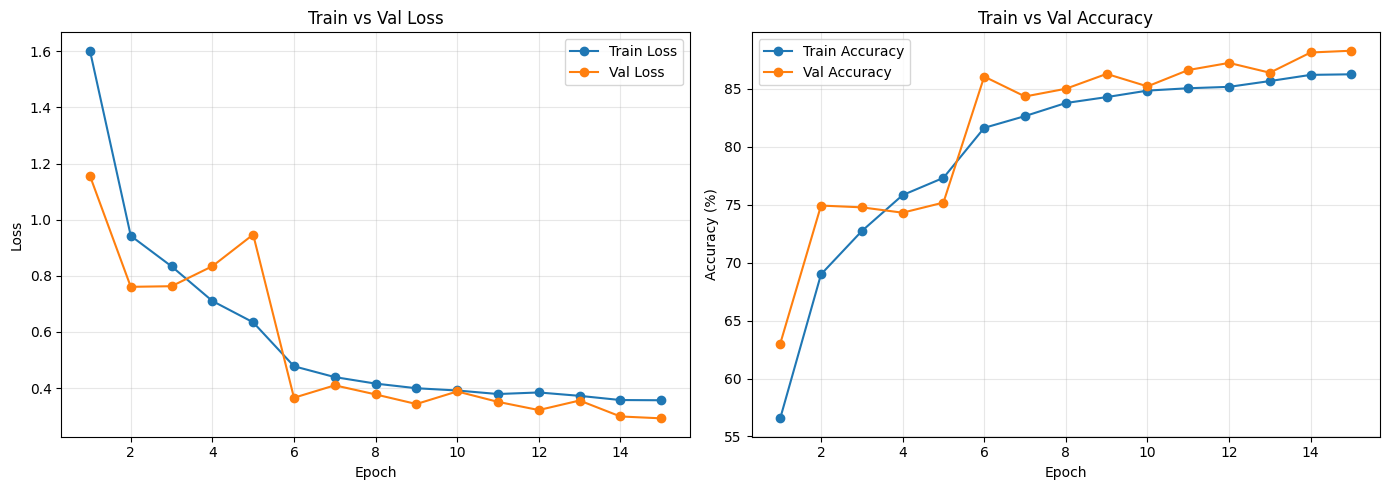

In [9]:
epochs_range = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(epochs_range, history['val_loss'], label='Val Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Train vs Val Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], label='Train Accuracy', marker='o')
axes[1].plot(epochs_range, history['val_acc'], label='Val Accuracy', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Train vs Val Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

test | Loss: 0.2986 | Accuracy: 88.31%
                  precision    recall  f1-score   support

      all_benign      0.986     0.946     0.966       148
       all_early      0.947     0.986     0.966       146
         all_pre      0.993     0.972     0.983       145
         all_pro      0.966     0.986     0.976       144
    brain_glioma      0.853     0.917     0.884       133
     brain_menin      0.704     0.851     0.770       134
     brain_tumor      0.898     0.642     0.749       137
   breast_benign      0.972     0.808     0.883       172
breast_malignant      0.784     0.978     0.870       137
      cervix_dyk      0.964     0.788     0.867       137
      cervix_koc      0.766     0.917     0.835       157
      cervix_mep      0.930     0.858     0.893       155
      cervix_pab      0.962     0.975     0.968       157
      cervix_sfi      0.832     0.941     0.883       169
       colon_aca      0.956     0.854     0.902       151
       colon_bnt      0.907     

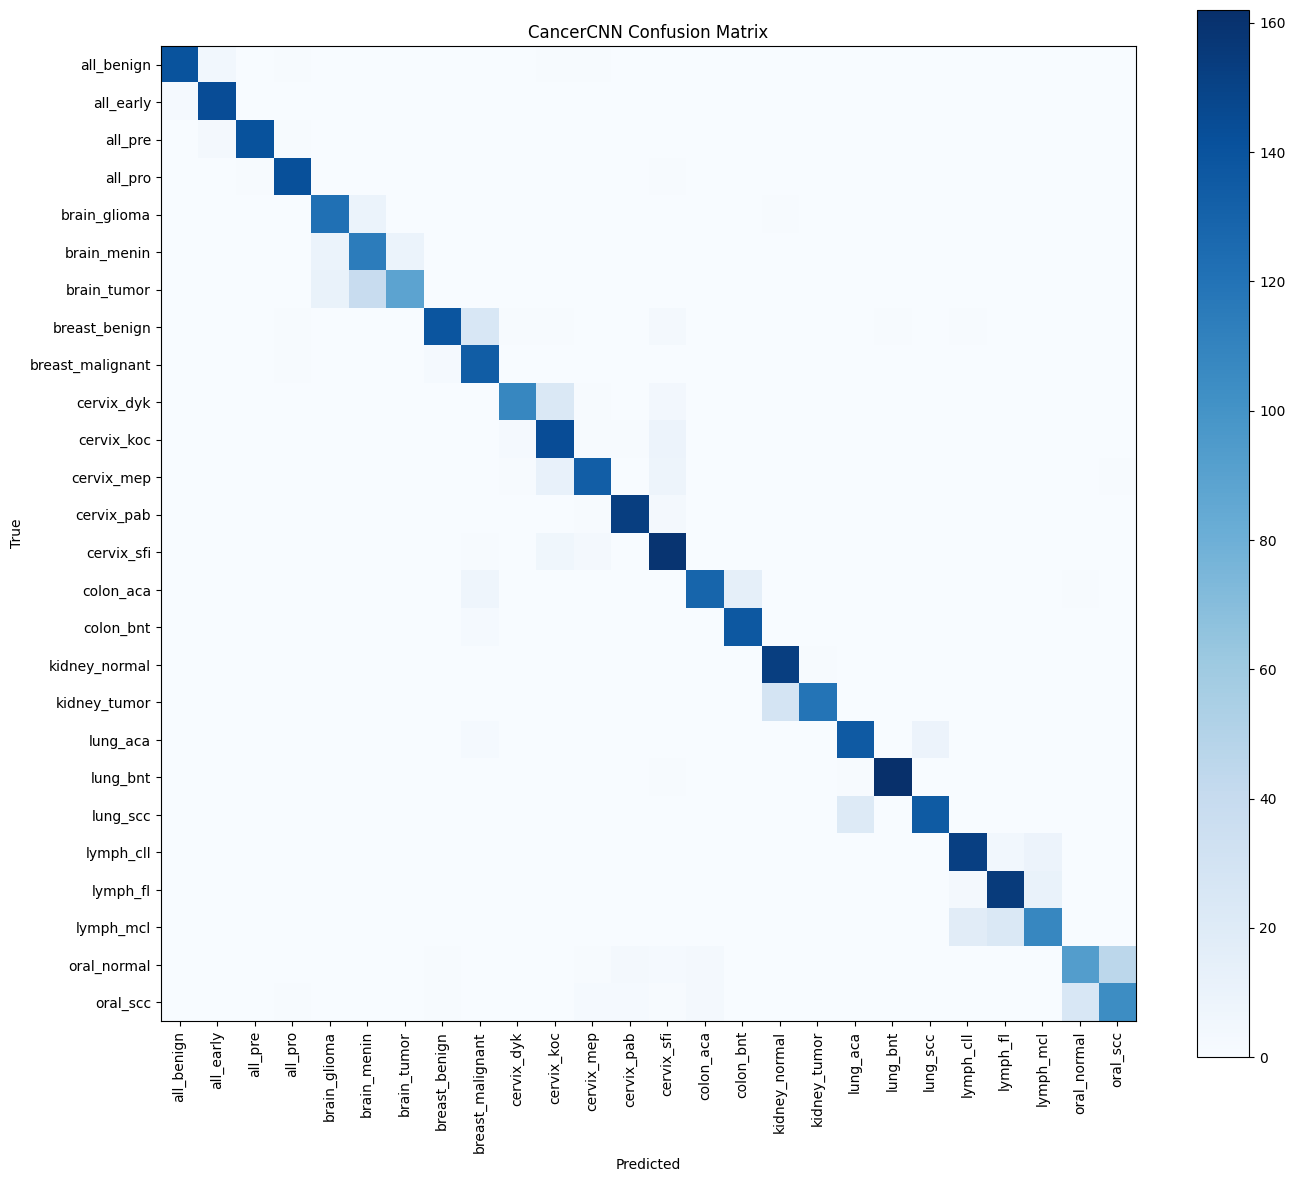

In [10]:
test_loss, test_acc, test_preds, test_targets = evaluate(test_loader, model, "test")

# Per-class precision/recall/F1 - this is the piece that was missing.
# Overall accuracy alone can hide a model that's great on common classes
# and terrible on rare/harder ones.
print(classification_report(test_targets, test_preds, target_names=class_names, digits=3))

cm = confusion_matrix(test_targets, test_preds)

plt.figure(figsize=(14, 12))
plt.imshow(cm, cmap='Blues')
plt.xticks(range(len(class_names)), class_names, rotation=90)
plt.yticks(range(len(class_names)), class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CancerCNN Confusion Matrix')
plt.colorbar()
plt.tight_layout()
plt.show()


In [11]:
!pip install -U transformers accelerate qwen-vl-utils --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 50.7 MB/s eta 0:00:00


In [12]:
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git" --quiet

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 18.7 MB/s eta 0:00:00


In [13]:
import unsloth
print(unsloth.__version__)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
2026.6.9


In [14]:
from unsloth import FastVisionModel
print("FastVisionModel imported successfully")

FastVisionModel imported successfully


In [15]:
from unsloth import FastVisionModel

qwen_model, qwen_processor = FastVisionModel.from_pretrained(
    "unsloth/Qwen2-VL-2B-Instruct",
    load_in_4bit=True,
)

==((====))==  Unsloth 2026.6.9: Fast Qwen2_Vl patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/572 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

Skipping model.language_model.layers.1.mlp.gate_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.up_proj: no quant_state found
Skipping model.language_model.layers.1.mlp.down_proj: no quant_state found


In [16]:
from transformers import AutoProcessor

qwen_processor = AutoProcessor.from_pretrained(
    "unsloth/Qwen2-VL-2B-Instruct",
    min_pixels=128 * 128,
    max_pixels=512 * 512,)
print(qwen_processor.image_processor.size)


preprocessor_config.json:   0%|          | 0.00/572 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

SizeDict(height=None, width=None, longest_edge=262144, shortest_edge=16384, max_height=None, max_width=None)


In [17]:
random.seed(42)
MAX_PER_CLASS = 150  

def build_sample(image_path, class_name):
    return {
        "messages": [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image_path},
                    {"type": "text", "text": "What type of cancer is shown in this histopathology image?"},
                ],
            },
            {
                "role": "assistant",
                "content": [{"type": "text", "text": class_name}],
            },
        ]
    }

train_samples = []

for class_name in sorted(os.listdir(flat_root)):
    class_dir = os.path.join(flat_root, class_name)
    if not os.path.isdir(class_dir):
        continue
    images = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sampled = random.sample(images, min(MAX_PER_CLASS, len(images)))
    for fname in sampled:
        img_path = os.path.join(class_dir, fname)
        train_samples.append(build_sample(img_path, class_name))

random.shuffle(train_samples)
print(f"Total training samples: {len(train_samples)}")  

Total training samples: 3900


In [18]:
qwen_model = FastVisionModel.get_peft_model(
    qwen_model,
    finetune_vision_layers=True,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,
    r=16,                  
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)

In [19]:
from trl import SFTTrainer, SFTConfig
from unsloth.trainer import UnslothVisionDataCollator

FastVisionModel.for_training(qwen_model)

trainer = SFTTrainer(
    model=qwen_model,
    tokenizer=qwen_processor,
    data_collator=UnslothVisionDataCollator(qwen_model, qwen_processor),
    train_dataset=train_samples,
    args=SFTConfig(
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    warmup_steps=10,
    num_train_epochs=1,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=10,
    optim="adamw_8bit",
    weight_decay=0.01,
    lr_scheduler_type="linear",
    seed=3407,
    max_seq_length=512,
    dataloader_num_workers=4,
    output_dir="/kaggle/working/qwen-cancer-finetune",
    report_to="none",
    ),
)

trainer_stats = trainer.train()

Unsloth: Model does not have a default image size - using 512


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3,900 | Num Epochs = 1 | Total steps = 244
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 2 x 1) = 16
 "-____-"     Trainable parameters = 28,950,528 of 2,237,936,128 (1.29% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
10,2.753257
20,0.959774
30,0.257114
40,0.075011
50,0.055922
60,0.052044
70,0.044055
80,0.040006
90,0.037574
100,0.036577


In [20]:
qwen_model.save_pretrained("/kaggle/working/qwen-cancer-finetuned")
qwen_processor.save_pretrained("/kaggle/working/qwen-cancer-finetuned")

['/kaggle/working/qwen-cancer-finetuned/processor_config.json']

In [21]:
import shutil
shutil.make_archive(
    "/kaggle/working/qwen-cancer-finetuned",  
    "zip",
    "/kaggle/working/qwen-cancer-finetuned"   
)

'/kaggle/working/qwen-cancer-finetuned.zip'

In [22]:
from transformers import AutoImageProcessor, AutoModel
phikon_processor = AutoImageProcessor.from_pretrained("owkin/phikon")
phikon_model = AutoModel.from_pretrained("owkin/phikon")
phikon_head = torch.nn.Linear(768, 26).to(device)

preprocessor_config.json:   0%|          | 0.00/171 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/492 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

phikon_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

phikon_processor = AutoImageProcessor.from_pretrained("owkin/phikon")
phikon_backbone = AutoModel.from_pretrained("owkin/phikon").to(device)
for param in phikon_backbone.parameters():
    param.requires_grad = False
phikon_backbone.eval()

cuda


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTModel(
  (embeddings): ViTEmbeddings(
    (patch_embeddings): ViTPatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): ViTEncoder(
    (layer): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (attention): ViTSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): ViTSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): ViTIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUActivation()
        )
        (output): ViTOutput(
          (d

In [24]:
random.seed(42)
base_dataset = datasets.ImageFolder(
    root='/kaggle/working/flat_dataset',
    transform=phikon_transform
)

indices = []
for class_idx in range(len(base_dataset.classes)):
    class_indices = [i for i, (_, label) in enumerate(base_dataset.samples) if label == class_idx]
    sampled = random.sample(class_indices, min(1000, len(class_indices)))
    indices.extend(sampled)

random.shuffle(indices)
n = len(indices)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

train_indices = indices[:train_end]
val_indices = indices[train_end:val_end]
test_indices = indices[val_end:]

train_subset = Subset(base_dataset, train_indices)
val_subset = Subset(base_dataset, val_indices)
test_subset = Subset(base_dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_subset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

class_names = base_dataset.classes
num_classes = len(class_names)
print(f"Classes: {num_classes} | Train: {len(train_indices)} | Val: {len(val_indices)} | Test: {len(test_indices)}")

Classes: 26 | Train: 18200 | Val: 3900 | Test: 3900


In [25]:
class PhikonClassifier(nn.Module):
    def __init__(self, backbone, num_classes=26):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Linear(768, num_classes)  # ViT-Base = 768 dim CLS token

    def forward(self, x):
        with torch.no_grad():
            outputs = self.backbone(x)
            # CLS token is the first token
            features = outputs.last_hidden_state[:, 0, :]
        return self.head(features)

phikon_model = PhikonClassifier(phikon_backbone, num_classes=num_classes).to(device)
optimizer = torch.optim.Adam(phikon_model.head.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
print("PhikonClassifier ready")

PhikonClassifier ready


In [26]:
# Training loop
num_epochs = 5 
phikon_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    print(f"--- Epoch {epoch+1}/{num_epochs} ---")
    phikon_model.train()
    running_loss, correct, total = 0.0, 0, 0

    loop = tqdm(train_loader, leave=True)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        scores = phikon_model(images)
        loss = loss_fn(scores, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (scores.argmax(1) == labels).sum().item()
        total += images.size(0)
        loop.set_postfix(loss=loss.item())

    train_loss = running_loss / total
    train_acc = correct / total * 100

    # Validation
    phikon_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            scores = phikon_model(images)
            loss = loss_fn(scores, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (scores.argmax(1) == labels).sum().item()
            val_total += images.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total * 100
    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    phikon_history['train_loss'].append(train_loss)
    phikon_history['train_acc'].append(train_acc)
    phikon_history['val_loss'].append(val_loss)
    phikon_history['val_acc'].append(val_acc)

--- Epoch 1/5 ---


100%|██████████| 143/143 [03:10<00:00,  1.33s/it, loss=0.352]


Train Loss: 0.4409 | Train Acc: 85.88% | Val Loss: 0.2059 | Val Acc: 93.18%
--- Epoch 2/5 ---


100%|██████████| 143/143 [03:09<00:00,  1.32s/it, loss=0.162]


Train Loss: 0.1625 | Train Acc: 94.93% | Val Loss: 0.1504 | Val Acc: 94.97%
--- Epoch 3/5 ---


...

Train Loss: 0.1192 | Train Acc: 96.33% | Val Loss: 0.1214 | Val Acc: 96.00%
--- Epoch 4/5 ---


100%|██████████| 143/143 [03:09<00:00,  1.33s/it, loss=0.0402]


Train Loss: 0.0945 | Train Acc: 97.20% | Val Loss: 0.1072 | Val Acc: 96.41%
--- Epoch 5/5 ---


100%|██████████| 143/143 [03:09<00:00,  1.32s/it, loss=0.0455]


Train Loss: 0.0821 | Train Acc: 97.42% | Val Loss: 0.0953 | Val Acc: 96.82%


In [27]:
phikon_model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        preds = phikon_model(images).argmax(1)
        all_preds.extend(preds.cpu().tolist())
        all_targets.extend(labels.cpu().tolist())

test_acc = sum(p == t for p, t in zip(all_preds, all_targets)) / len(all_targets) * 100
print(f"Test Accuracy: {test_acc:.2f}%")
print(classification_report(all_targets, all_preds, target_names=class_names, digits=3))

Test Accuracy: 97.23%
                  precision    recall  f1-score   support

      all_benign      0.993     0.986     0.990       148
       all_early      0.986     1.000     0.993       146
         all_pre      0.993     1.000     0.997       145
         all_pro      1.000     0.993     0.997       144
    brain_glioma      0.970     0.985     0.978       133
     brain_menin      0.885     0.918     0.901       134
     brain_tumor      0.938     0.883     0.910       137
   breast_benign      0.994     1.000     0.997       172
breast_malignant      1.000     0.993     0.996       137
      cervix_dyk      0.985     0.964     0.974       137
      cervix_koc      0.923     0.987     0.954       157
      cervix_mep      0.993     0.948     0.970       155
      cervix_pab      0.994     1.000     0.997       157
      cervix_sfi      1.000     0.988     0.994       169
       colon_aca      1.000     1.000     1.000       151
       colon_bnt      1.000     1.000     1.000  

In [28]:
torch.save({
    'head_state_dict': phikon_model.head.state_dict(),
    'class_names': class_names,
}, '/kaggle/working/phikon_head.pt')
print("Phikon saved")

Phikon saved


In [29]:
save = model.module if hasattr(model, 'module') else model

torch.save(save.state_dict(), '/kaggle/working/cancer_cnn.pt')
print("CancerCNN saved")

CancerCNN saved


In [30]:
!python --version


Python 3.12.13
